# GBM Examples Notebook

Original QMCPy demo: [`QMCPy/demos/GBM/gbm_examples.ipynb`](../../../QMCPy/demos/GBM/gbm_examples.ipynb)

The Python notebook compares helper modules and MAE plots for GBM samplers. This Julia translation keeps the same theme by comparing terminal-value errors and an Asian-option estimate with built-in `QMC.jl` tools.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/GBM/gbm_examples.ipynb)

In [1]:
using QMC
using Statistics
using Printf

# Plots.jl is optional; guard plot cells so the notebook runs in headless CI.
const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


## Configuration

We work with a geometric Brownian motion model

$$S(t) = S_0 \exp\!\left((\gamma - 	\frac{\sigma^2}{2}) t + \sigma W(t)
\right),$$

and compare how the sampling error changes with the number of simulated paths.


In [2]:
S0 = 100.0
γ = 0.05
σ2 = 0.04
T = 1.0
d = 8
ns = 2 .^ (7:11)
exact_terminal_mean = S0 * exp(γ * T)

function terminal_mean_error(dd)
    tm = GeometricBrownianMotion(dd; t_final=T, initial_value=S0, drift=γ, diffusion=σ2)
    x = transform(tm, gen_samples(dd, ns[end]))
    return [abs(mean(x[1:n, end]) - exact_terminal_mean) for n in ns]
end

iid_errors = terminal_mean_error(IIDStdUniform(d; seed=7))
lattice_errors = terminal_mean_error(Lattice(d; seed=7))
net_errors = terminal_mean_error(DigitalNetB2(d; seed=7, graycode=false))

println("path counts = ", ns)
println("IID errors = ", round.(iid_errors, digits=4))
println("Lattice errors = ", round.(lattice_errors, digits=4))
println("Digital net errors = ", round.(net_errors, digits=4))


path counts = 

[128, 256, 512, 1024, 2048]
IID errors = 

[3.5637, 2.5423, 1.1599, 0.1958, 0.3603]
Lattice errors = [0.0263, 0.1759, 0.093, 0.0182, 0.0157]
Digital net errors = [0.1431, 0.2135, 0.0169, 0.0209, 0.0688]


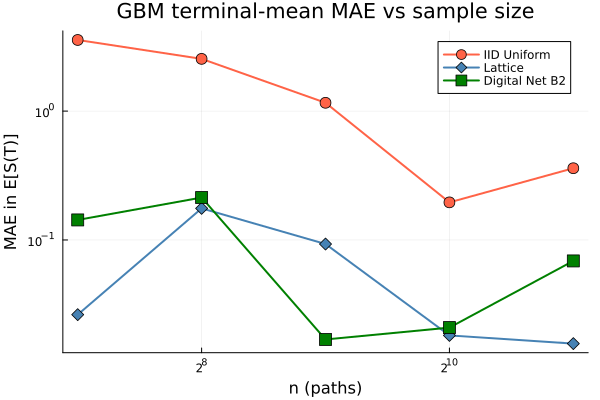

In [3]:
if HAVE_PLOTS
    p = plot(ns, iid_errors;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=6, color=:tomato, label="IID Uniform",
        xlabel="n (paths)", ylabel="MAE in E[S(T)]",
        title="GBM terminal-mean MAE vs sample size")
    plot!(ns, lattice_errors;
        marker=:diamond, lw=2, ms=6, color=:steelblue, label="Lattice")
    plot!(ns, net_errors;
        marker=:square, lw=2, ms=6, color=:green, label="Digital Net B2")
    display(p)
end


## MAE vs Number of Paths

The exact mean of the terminal stock price is available in closed form, so the absolute error of the empirical terminal mean plays the role of the MAE comparison used in the Python notebook.


In [4]:
@assert minimum(lattice_errors) < maximum(iid_errors)
@assert minimum(net_errors) < maximum(iid_errors)


## Asian Option Example

As a second GBM-based example, we price a geometric-average Asian call option using a randomized lattice rule.


In [5]:
tm_option = BrownianMotion(Lattice(12; seed=7); t_final=1.0)
asian_call = FinancialOption(tm_option; option_type=:asian, call_put=:call, mean_type=:geometric, volatility=0.5, start_price=30.0, strike_price=25.0, interest_rate=0.0)
result_option = integrate(CubQMCLatticeG(asian_call; abs_tol=5e-3))
@printf("Geometric Asian call price estimate = %.6f using n_total = %d
", result_option.solution, result_option.data[:n_total])
@printf("Closed-form benchmark used by QMC.jl = %.6f
", get_exact_value(asian_call))

@assert abs(result_option.solution - get_exact_value(asian_call)) < 0.1


Geometric Asian call price estimate = 5.948500 using n_total = 16384
Closed-form benchmark used by QMC.jl = 5.951824


## Sample Paths Visualization


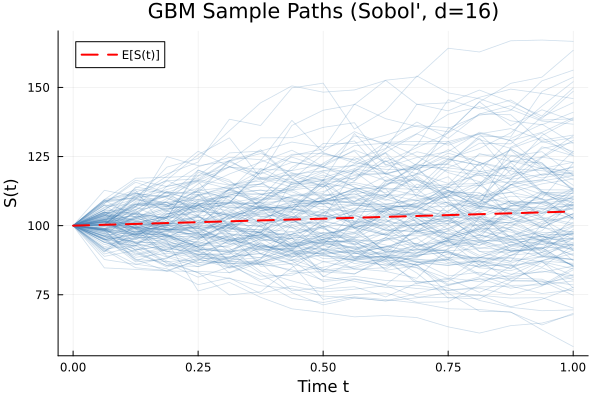

In [6]:
if HAVE_PLOTS
    S0_plot, γ_plot, σ2_plot = 100.0, 0.05, 0.04
    T_plot = 1.0
    d_plot = 16
    n_show = 150
    dd_plt = DigitalNetB2(d_plot; seed=7)
    gbm_plt = GeometricBrownianMotion(dd_plt;
        t_final=T_plot, initial_value=S0_plot, drift=γ_plot, diffusion=σ2_plot)
    x_plt = gen_samples(dd_plt, n_show)
    paths_plt = transform(gbm_plt, x_plt)
    t_plt = [0.0; gbm_plt.time_vector]
    S_plt = hcat(fill(S0_plot, n_show), paths_plt)  # n_show × (d_plot+1)
    p = plot(t_plt, S_plt';
        alpha=0.25, color=:steelblue, lw=0.8, label=nothing,
        xlabel="Time t", ylabel="S(t)",
        title="GBM Sample Paths (Sobol', d=$d_plot)")
    E_line = S0_plot .* exp.(γ_plot .* gbm_plt.time_vector)
    plot!([0.0; gbm_plt.time_vector], [S0_plot; E_line];
        color=:red, lw=2, linestyle=:dash, label="E[S(t)]")
    display(p)
end
